- get experiment raw path
- load xml file
- load voltage data
- pull timestamps

-

In [54]:
import glob
import os
import h5py
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from src import io, vis

In [14]:
# get experiment raw path
# need os, glob
def get_base_path(experiment_id, raw = None, processed = None, base_dir = '/Volumes/AhmedLab/princess/data/'):
    # only one can be true
    experiment_id = str(experiment_id)
    if raw == True:
        experiment_path = glob.glob(os.path.join(base_dir, 'raw', f'*{experiment_id}'))[0]
    if processed == True:
        experiment_path = glob.glob(os.path.join(base_dir, 'processed', f'*{experiment_id}'))[0]

    return experiment_path


def load_voltage_data(experiment_path):
    """
    Loads voltage data and pulls out timestamps into arrays
    """
    file = glob.glob(os.path.join(experiment_path,'*.csv'))[0]
    data = pd.read_csv(file)

    # determine signal source by comparing average voltage from Carter's script
    # data.columns = data.columns.str.strip()
    # column_means = np.floor(data.mean())

    camera_timestamps = pull_timestamps_ms(data['Time(ms)'], data[' Input 2'], threshold=3)
    maui_timestamps = pull_timestamps_ms(data['Time(ms)'], data[' Input 1'], threshold=4)

    return camera_timestamps, maui_timestamps

def pull_timestamps_ms(time_array, signal_array, threshold):
    binarized_signal = []
    for signal in signal_array:
        if signal > threshold:
            binarized_signal.append(1)
        else:
            binarized_signal.append(0)

    # get frame starts by finding +1 changes
    # add [0] because diff loses the first value
    signal_changes = [0] + np.diff(binarized_signal)

    timestamps = []
    for i, val in enumerate(signal_changes):
        if val == 1:
            timestamps.append(time_array[i])

    return pd.DataFrame(timestamps)

def load_xml_timestamps(experiment_path):
    file = glob.glob(os.path.join(experiment_path,'*.xml'))[0]

    tree = ET.parse(file)
    root = tree.getroot()
    xml_frames = []
    for element in root.iter("Frame"):
        time = float(element.attrib['relativeTime'])
        xml_frames.append(time)

    xml_frames_ms = [x*1000 for x in xml_frames]
    return pd.DataFrame(xml_frames_ms)

def plot_timestamps(source1, source2 = None, xlims = None):
    fig, ax = plt.subplots()
    ax.vlines(source1, 0, 1, color='red', alpha=0.8)
    if source2 is not None:
        ax.vlines(source2, 0, 0.5, color='green', alpha=0.8)

    plt.xlabel('Time (ms)')
    if xlims is not None:
        plt.xlim(xlims[0], xlims[1])


def pull_nearest_timestamps(xml_frames, ttl_frames):
    true_timestamps = []
    for xml_frame in xml_frames[0]:
        differences = np.abs(ttl_frames[0]-xml_frame)

        #  find ttl timestamp closest to the xml timestamp
        nearest_index = differences.idxmin()
        # assign true timestamp to the ttl time
        nearest_value = maui_ttl_ms[0].iloc[nearest_index]
        true_timestamps.append(nearest_value)
    return pd.DataFrame(true_timestamps)

In [3]:
raw_path = get_base_path(101, raw = True)
processed_path = get_base_path(101, processed = True)

# voltage_data = load_voltage_csv(raw_path)
camera_ttl_ms, maui_ttl_ms = load_voltage_data(raw_path)
xml_maui_timestamps = load_xml_timestamps(raw_path)

Text(0.5, 0, 'Time (ms)')

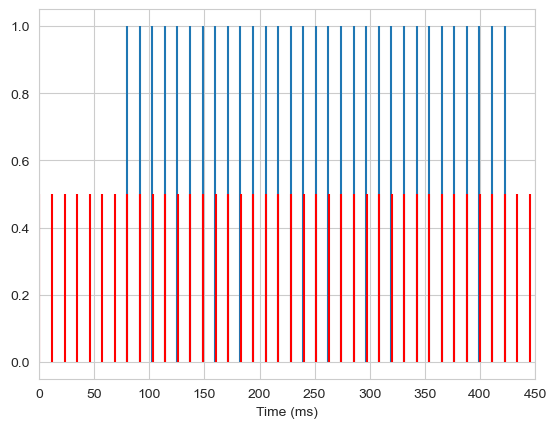

In [7]:
plt.vlines(xml_maui_timestamps, 0, 1, label='XML frames')
plt.vlines(maui_ttl_ms, 0, 0.5, colors='r', label='TTL frames')

plt.xlim(0,450)
plt.xlabel('Time (ms)')

In [ ]:
# calculate volume rate + flyback times


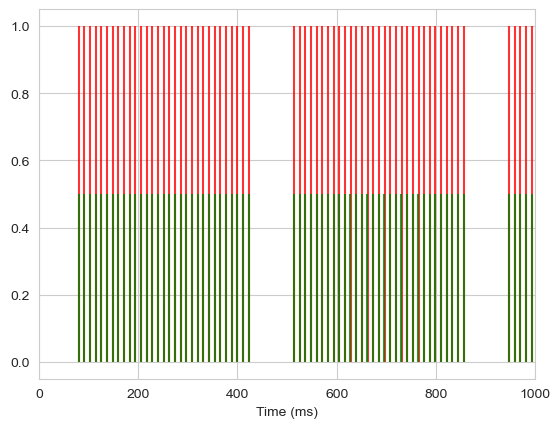

In [60]:
maui_ttl_timestamps = pull_nearest_timestamps(xml_maui_timestamps, maui_ttl_ms)
plot_timestamps(maui_ttl_timestamps, xml_maui_timestamps, xlims = [0,1000])

In [88]:
cluster_labels, signal = io.load_clusters(processed_path)
scope_fr, camera_fr, brain_dim = io.load_acquisition_params(processed_path)

In [80]:
print(cluster_labels.shape, signal.shape)
print(brain_dim)

(31, 43520) (31, 500, 2767)
[ 256  170   31 2767]


(2767,) [2.51331290e-01 6.85072581e-01 1.11880871e+00 ... 1.19914615e+03
 1.19957989e+03 1.20001364e+03]


Text(0.5, 0, 'Time (s)')

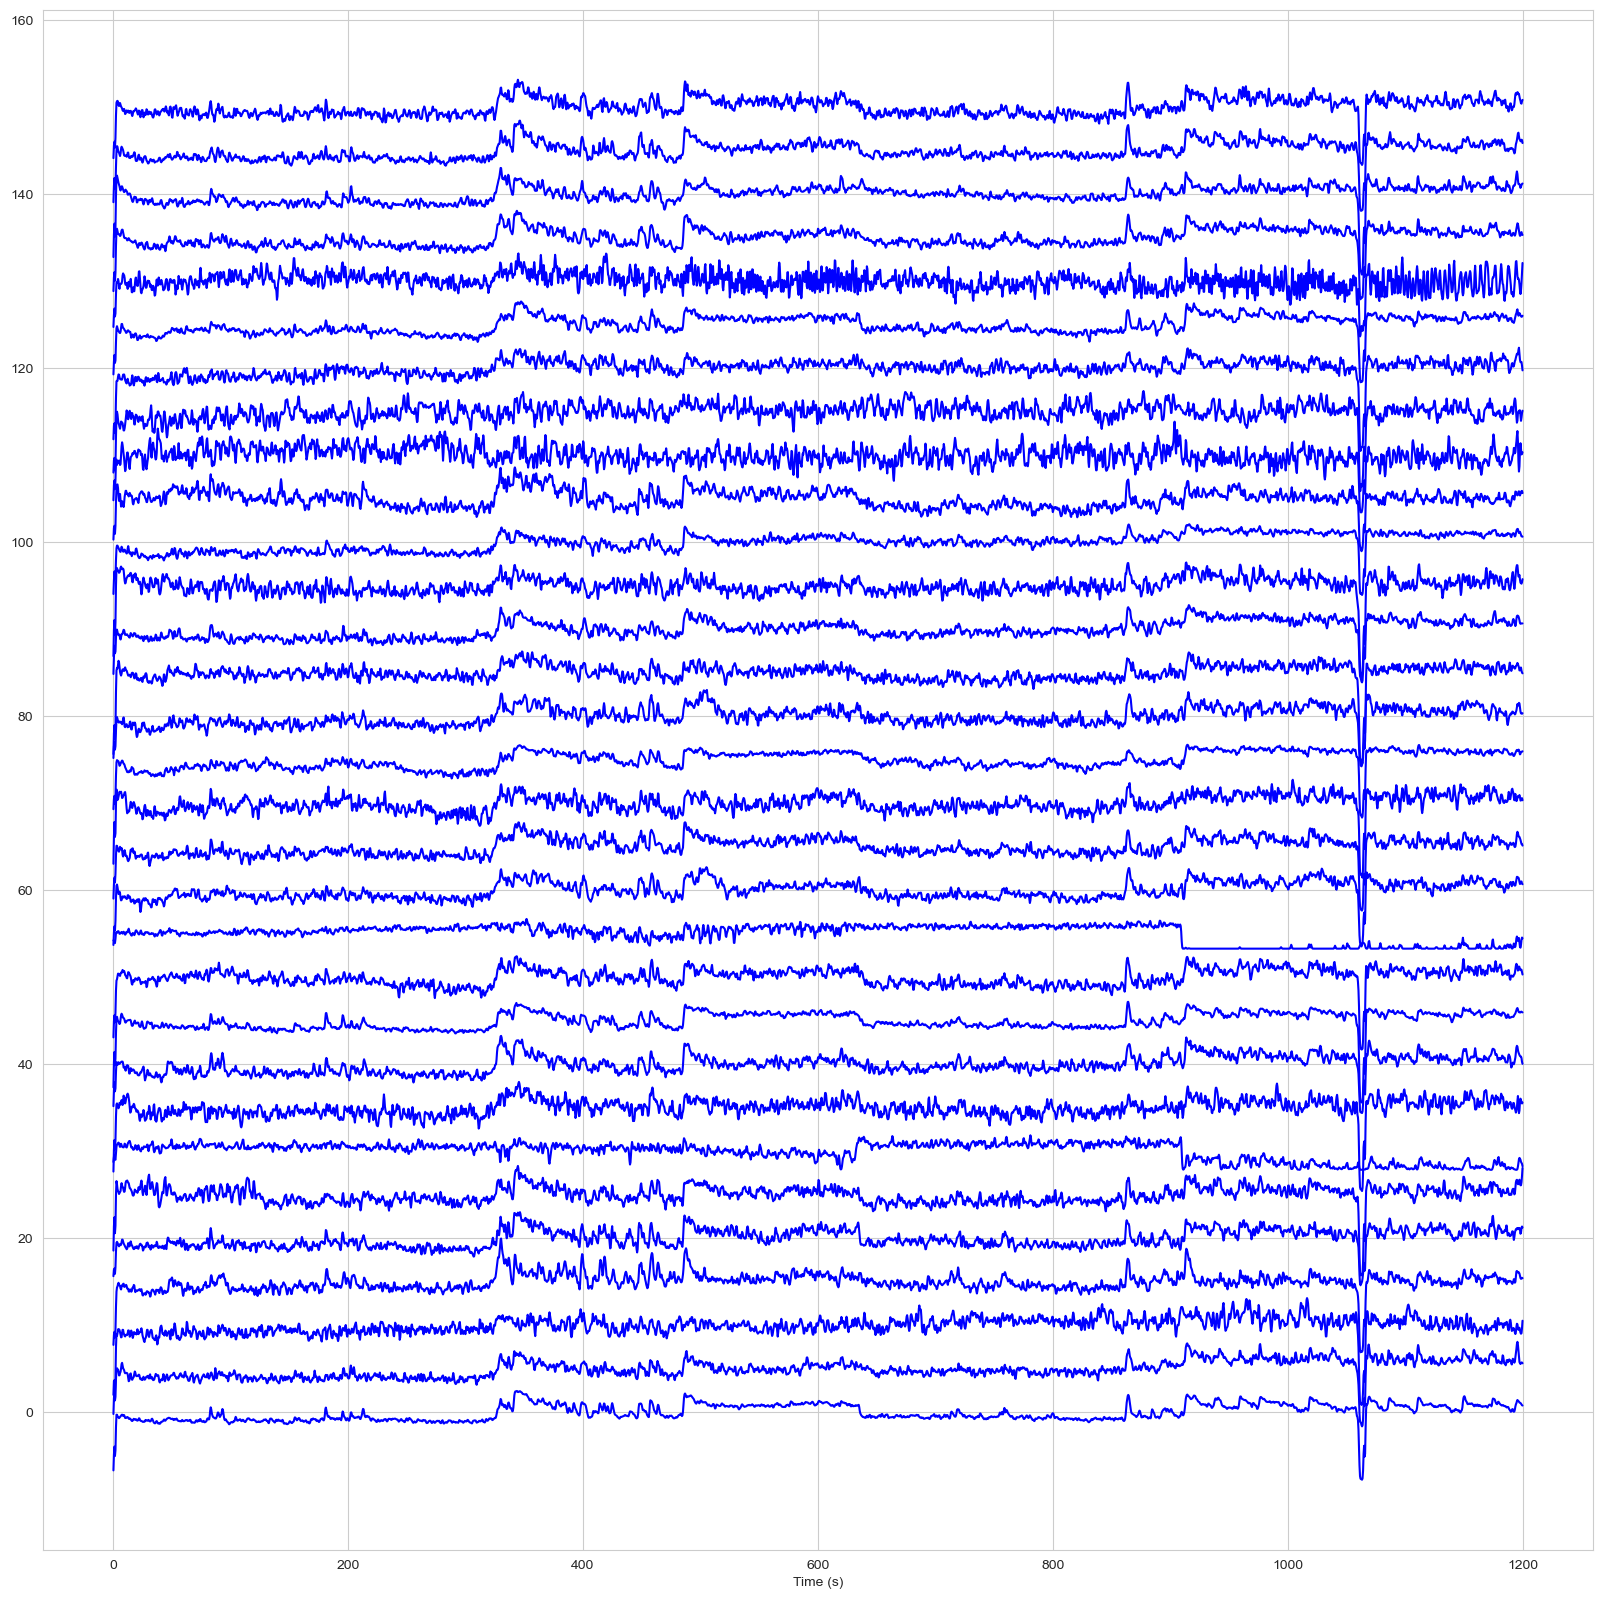

In [120]:
maui_volume_time = np.reshape(maui_ttl_timestamps, [signal.shape[-1],-1])
# print(maui_volume_time[0:2], maui_volume_time.shape)
# plot slice1, 10 clusters, with correct time

# pull times from down column
single_slice_time_s = (maui_volume_time.mean(axis=1))/1000
print(single_slice_time_s.shape, single_slice_time_s)
vis.plot_raw_calcium_traces(single_slice_time_s, signal[15])
plt.xlabel('Time (s)')

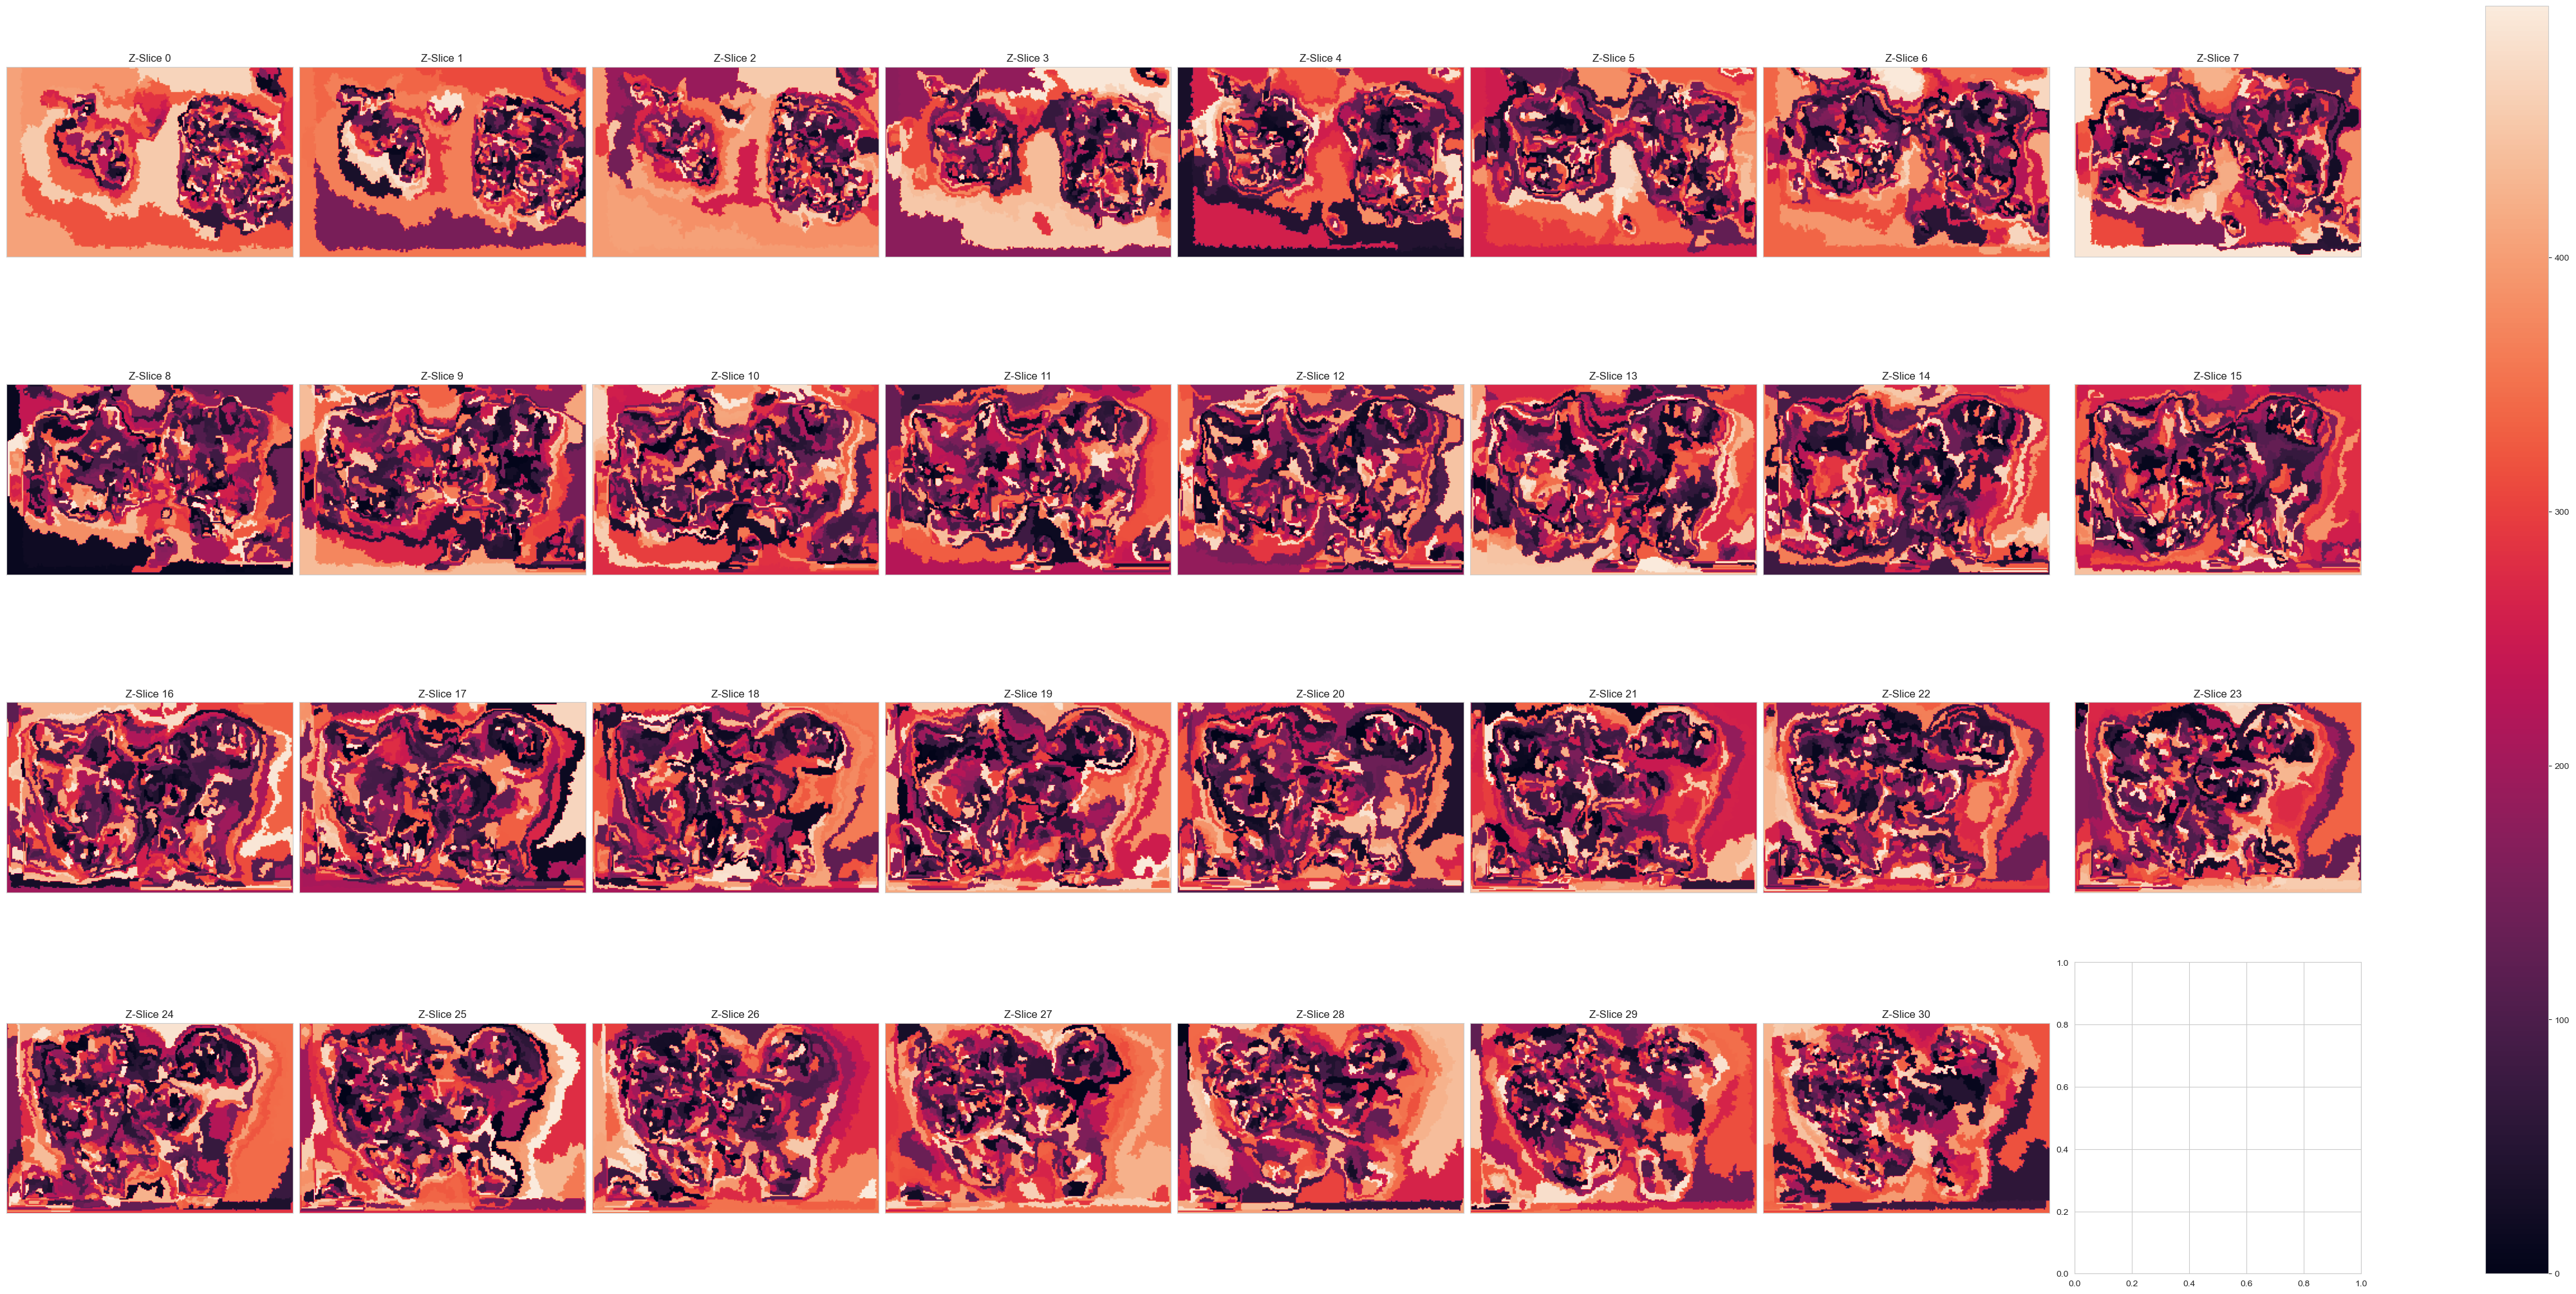

In [121]:
# plot one spatial and one calcium
single_slice = 19
single_cluster = 100

one_signal = signal[single_slice,single_cluster]
# to get a spatial of a single cluster
# reshape clusters into brain shape
brain_clusters = cluster_labels.reshape(brain_dim[2], brain_dim[0], brain_dim[1])
vis.plot_spatial_clusters(brain_clusters)

In [150]:
blank_brain = np.zeros(cluster_labels.shape)

# blank_brain[0,10] = 5
# blank_brain[0,10]

(43520,)
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[431 431 431 ... 431 431 431]
[

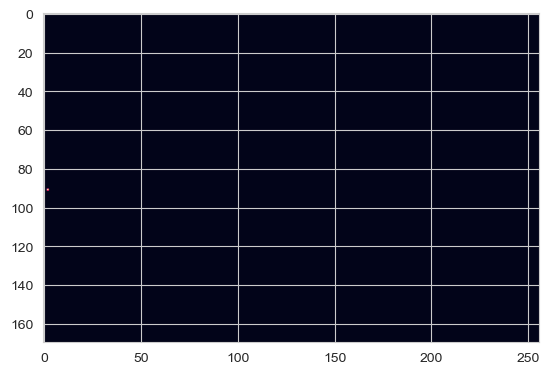

In [163]:


for slice, pixels in enumerate(cluster_labels):
    if slice == single_slice:
        print(pixels.shape)
        for value in pixels:
            # print(cluster_labels[slice,pixels])
            if value == 100:
                print(cluster_labels[slice,pixels])
                # blank_brain[0,value] = 100
                # print(cluster_labels[slice,value])
                # blank_brain[id] = cluster_labels[slice,id]
            # loop over cluster_labels[slice, a]
            # if cluster_labels[slice,a] == 7:
            #     print(i)
                # blank_brain[slice,a] = cluster_labels[slice,a]
            # test = cluster_labels[slice, a]
            # print(np.where(cluster_labels[slice, a] == single_cluster))
# plt.plot(blank_brain[0])
blank_brain_clusters = blank_brain.reshape(brain_dim[2], brain_dim[0], brain_dim[1])
plt.imshow(blank_brain_clusters[0].T)